In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
raw_data = pd.read_parquet("data/processed/category_daily_raw.parquet")
raw_data.head()

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1.0,nan,nan,nan,nan,1,1,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
4,FOODS_1_001_CA_1,2011-02-02,4.0,nan,nan,nan,nan,1,0,1,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA


In [3]:
daily_sales = raw_data.groupby('ds', observed=True).agg({'y': 'sum'})
daily_sales.head()

,y
ds,
2011-01-29,32631.0
2011-01-30,31749.0
2011-01-31,23783.0
2011-02-01,25412.0
2011-02-02,19146.0


Text(0, 0.5, 'unist Sold')

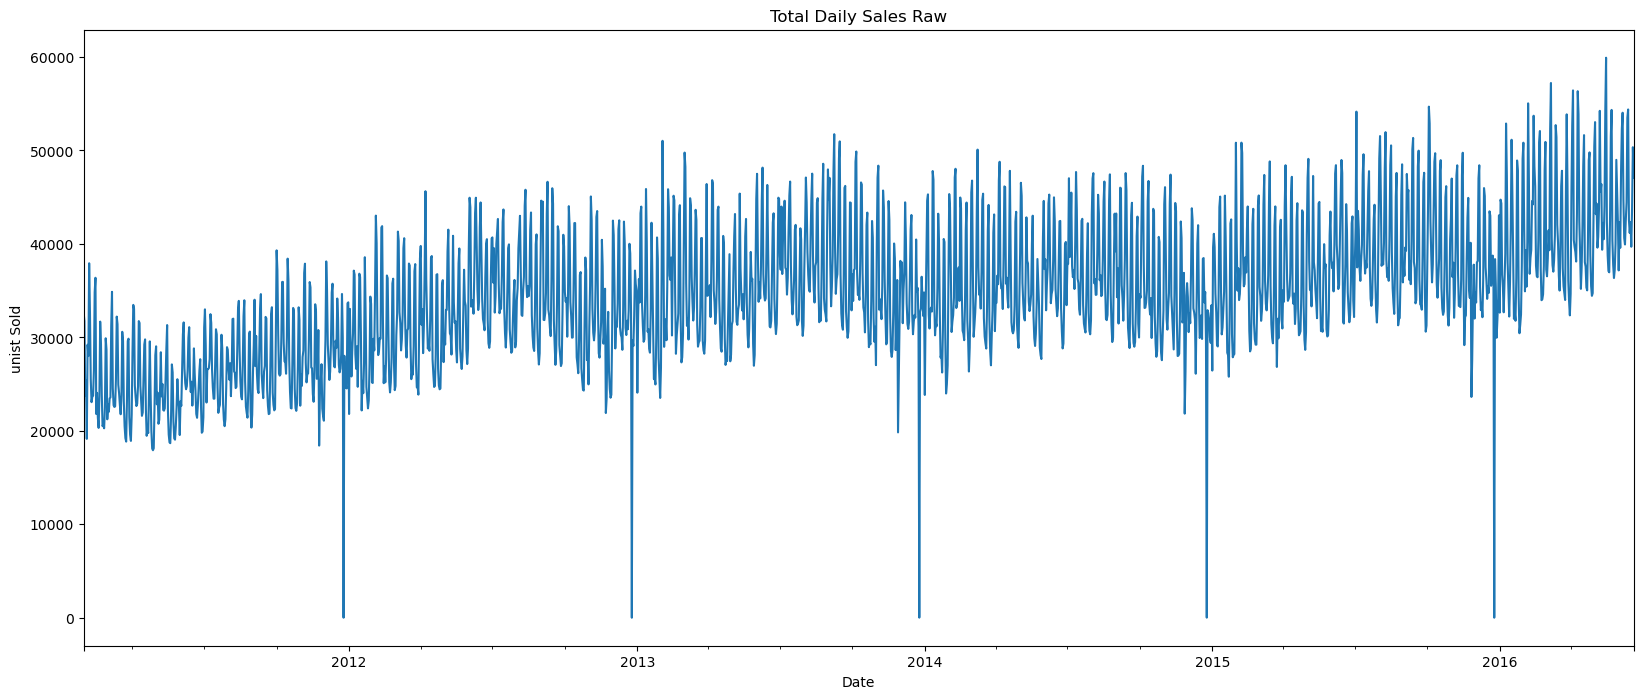

In [12]:
daily_sales.plot(legend=False, figsize=(20,8))
plt.title("Total Daily Sales Raw")
plt.xlabel('Date')
plt.ylabel("unist Sold")

In [13]:
raw_data.head()

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1.0,nan,nan,nan,nan,1,1,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
4,FOODS_1_001_CA_1,2011-02-02,4.0,nan,nan,nan,nan,1,0,1,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA


In [17]:
event_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']

In [42]:
christmas_mask = (
    raw_data['event_name_1'].str.contains('christmas', case=False, na=False)
    | raw_data['event_name_2'].str.contains('christmas', case=False, na=False)
)

christmas_mask.sum()

np.int64(249014)

In [20]:
event_names = pd.unique(
    raw_data[['event_name_1', 'event_name_2']].values.ravel()
)

event_names

array(['nan', 'SuperBowl', 'ValentinesDay', 'PresidentsDay', 'LentStart',
       'LentWeek2', 'StPatricksDay', 'Purim End', 'OrthodoxEaster',
       'Easter', 'Pesach End', 'Cinco De Mayo', "Mother's day",
       'MemorialDay', 'NBAFinalsStart', 'NBAFinalsEnd', "Father's day",
       'IndependenceDay', 'Ramadan starts', 'Eid al-Fitr', 'LaborDay',
       'ColumbusDay', 'Halloween', 'EidAlAdha', 'VeteransDay',
       'Thanksgiving', 'Christmas', 'Chanukah End', 'NewYear',
       'OrthodoxChristmas', 'MartinLutherKingDay'], dtype=object)

In [29]:
daily_sales[daily_sales['y']<150]

,y
ds,
2011-12-25,13.0
2012-12-25,11.0
2013-12-25,20.0
2014-12-25,20.0
2015-12-25,14.0


In [45]:
raw_data.loc[
    christmas_mask,
    ['ds', 'event_name_1', 'event_name_2']
]

,ds,event_name_1,event_name_2
330,2011-12-25,Christmas,nan
343,2012-01-07,OrthodoxChristmas,nan
696,2012-12-25,Christmas,nan
709,2013-01-07,OrthodoxChristmas,nan
1061,2013-12-25,Christmas,nan
...,...,...,...
47649045,2014-01-07,OrthodoxChristmas,nan
47649397,2014-12-25,Christmas,nan
47649410,2015-01-07,OrthodoxChristmas,nan
47649762,2015-12-25,Christmas,nan


## Build the core category-level views

We keep three related category-level tables throughout the notebook:

- `category_daily_event_enriched`: the same sales totals enriched with event and calendar flags for diagnostics
- `category_daily_normalized`: a diagnostic-only view that excludes December 25 so one extreme holiday does not dominate certain charts

Important: December 25 is **not** deleted from the raw data. It stays in the raw and event-aware views. It is only excluded from the normalized diagnostic view.


In [35]:
category_daily_event_enriched = raw_data.copy()
category_daily_event_enriched.head()

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1.0,nan,nan,nan,nan,1,1,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
4,FOODS_1_001_CA_1,2011-02-02,4.0,nan,nan,nan,nan,1,0,1,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA


In [40]:
category_daily_event_enriched.shape

(47649940, 16)

In [38]:
category_daily_normalized = raw_data[raw_data['event_name_1']!='Christmas'].copy()
category_daily_normalized.head()

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1.0,nan,nan,nan,nan,1,1,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
4,FOODS_1_001_CA_1,2011-02-02,4.0,nan,nan,nan,nan,1,0,1,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA


In [41]:
category_daily_normalized.shape

(47525714, 16)